# Управление данными в Pandas. Дополнительные возможности



[Официальный сайт библиотеки](https://pandas.pydata.org/)

[Руководство пользователя 1](https://pythonist.ru/polnoe-rukovodstvo-po-pandas-dlya-nachinayushhih/)

[Руководство пользователя 2](https://pandas.pydata.org/docs/user_guide/index.html)


В данном блокноте разбираются некоторые дополнительные возможности управления данными в Pandas. Будет рассмотрена лишь небольшая часть из богатого функционала библиотеки. Можно продолжить его освоение, изучая литературу, многочисленные статьи на различных Интернет-ресурсах, а также руководства пользователя, ссылки на которые приведены в начале этого блокнота.

## Подключение библиотек

In [1]:
import pandas as pd
import numpy as np

## 1. Математика над DataFrame

### Арифметические операции

Для разбора примеров создадим простой числовой датафрейм:




In [2]:
df_m = pd.DataFrame(np.linspace(-5,6,12).reshape(4, 3),
                  index=['ind_1', 'ind_2', 'ind_3', 'ind_4'],
                  columns=['A', 'B', 'C'])
df_m

,A,B,C
ind_1,-5.0,-4.0,-3.0
ind_2,-2.0,-1.0,0.0
ind_3,1.0,2.0,3.0
ind_4,4.0,5.0,6.0


Умножим все значения на 1.2, затем заменим все результаты их модулем:

In [3]:
df_m = abs(df_m * 1.2)
df_m

,A,B,C
ind_1,6.0,4.8,3.6
ind_2,2.4,1.2,0.0
ind_3,1.2,2.4,3.6
ind_4,4.8,6.0,7.2


Вычтем первую строку из каждой строки фрейма.

Удобнее использовать числовой индекс первой строки (0 - номер строки по порядку), а не её строковый индекс <b>ind_1</b>, поэтому для доступа к элементам строки используем свойство <b>.iloc</b>.

In [4]:
df_m = df_m - df_m.iloc[0]
df_m

,A,B,C
ind_1,0.0,0.0,0.0
ind_2,-3.6,-3.6,-3.6
ind_3,-4.8,-2.4,0.0
ind_4,-1.2,1.2,3.6


Выполним более сложные манипуляции:
- сформируем новый фрейм s из фрейма df_m, сохранив  значения, стоящие во втором и третьем столбце <code>[1:3]</code> 4-ой строки <code>[3]</code>:
- в новом фрейме s добавим нулевой столбец с имененм <b>E</b>

Обратите внимание: в новом фрейме s всего одна строка, поэтому он выводится на консоль, как серия (в виде столбца).

In [5]:
s = df_m.iloc[3][1:3]
s['E'] = 0
s

,ind_4
B,1.2
C,3.6
E,0.0


Найдем сумму двух полученных ранее фреймов:

In [6]:
df_m = df_m + s
df_m

,A,B,C,E
ind_1,NaN,1.2,3.6,NaN
ind_2,NaN,-2.4,0.0,NaN
ind_3,NaN,-1.2,3.6,NaN
ind_4,NaN,2.4,7.2,NaN


**Пояснение**. В первом слагаемом суммы (во фрейме df_m) не было столбца E, а во втором слагаемом (фрейме s) не было столбца A, поэтому столбцы A при E выполнении сложения воспринимались, как несуществующие
значения (NaN - not a number).

Отсюда и полученный результат: два столбца с NaN.

## 2. Слияние, объединение и конкатенация данных</font>

При работе с несколькими фреймами данных может возникнуть задача объединить данные разных фреймов в один общий фрейм.

Инструментарий Pandas позволяет это сделать несколькими разными способами.

### Конкатенация (**concatenate**)
Самый простой способ объединения фреймов — конкатенация (склеивание), знакомая программистам по работе со строками. Фреймы данных в Pandas прямоугольные, поэтому склеивать их можно по вертикали: второй под первым (вдоль оси 0), или по горизонтали: второй справа от первого (вдоль оси 1).

Для примера создадим три небольших датафрейма и применим к ним оба способа конкатенации:

In [7]:
df1 = pd.DataFrame(np.array([1,2,3,4,5,6,7,8,9]).reshape(3, 3),
                  index=['1', '2', '3'],
                  columns=['c1', 'c2', 'c3'])
df1

,c1,c2,c3
1,1,2,3
2,4,5,6
3,7,8,9


In [8]:
df2 = pd.DataFrame(np.array([11,12,13,14,15,16]).reshape(2, 3),
                  index=['3', '4'],
                  columns=['c1', 'c2', 'c3'])
df2

,c1,c2,c3
3,11,12,13
4,14,15,16


In [9]:
df3 = pd.DataFrame(np.array([21,22,23,24,25,26]).reshape(3, 2),
                  index=['1', '2', '3'],
                  columns=['c3', 'c4'])
df3

,c3,c4
1,21,22
2,23,24
3,25,26


Склеим первые два датафрейма сначала по вертикали ,а потом по горизонтали:

In [10]:
pd.concat([df1, df2], axis=0)

,c1,c2,c3
1,1,2,3
2,4,5,6
3,7,8,9
3,11,12,13
4,14,15,16


In [11]:
pd.concat([df1, df2], axis=1)

,c1,c2,c3,c1,c2,c3
1,1.0,2.0,3.0,NaN,NaN,NaN
2,4.0,5.0,6.0,NaN,NaN,NaN
3,7.0,8.0,9.0,11.0,12.0,13.0
4,NaN,NaN,NaN,14.0,15.0,16.0


Как видим, по вертикали имеет смысл склеивать фреймы с одинаковым набором столбцов. Если такие фреймы склеить по горизонтали, то колонки дублируются с появлением пустых ячеек.

Выполним аналогичные операции между 1 и 3 фреймами:


In [12]:
pd.concat([df1, df3], axis=0)

,c1,c2,c3,c4
1,1.0,2.0,3,NaN
2,4.0,5.0,6,NaN
3,7.0,8.0,9,NaN
1,NaN,NaN,21,22.0
2,NaN,NaN,23,24.0
3,NaN,NaN,25,26.0


In [13]:
pd.concat([df1, df3], axis=1)

,c1,c2,c3,c3,c4
1,1,2,3,21,22
2,4,5,6,23,24
3,7,8,9,25,26


Понятно, что по горизонтали имеет смысл склеивать фреймы с одинаковыми наборами индексов.

Для примера: вернемся еще раз к фрейму **group**, рассмотренному в основной части учебного материала (блокнот "2_1_Знакомство_с_библиотекой_Pandas").

In [14]:
group = pd.read_csv('stats.csv',  sep = ',')
group.head()

,Name,Sex,Age,Height,Weight
0,Alex,M,41,74,170
1,Bert,M,42,68,166
2,Carl,M,32,70,155
3,Dave,M,39,72,167
4,Elly,F,30,66,124


Если в дальнейшем появится фрейм с тем же набором столбцов, что и **group**, но с информацией о других людях, его можно будет "подклеить" к group по вертикали (axes=0). А если появится фрейм с адресами проживания людей из **group**, (но с такими же индексами!), то его можно будет "подклеить" к **group** по горизонтали (axes=1).

### Объединение (**join**)
Эта операция предполагает присоединение к исходному фрейму данных другого фрейма <u>с другими именами столбцов</u> на основе общности индексов. При этом могут быть разные варианты обработки несовпадающих индексов:
- **inner join** (по умолчанию)  - внутреннее объединение: в результат объединения войдут строки, индексы которых есть в обоих объединяемых фреймах (таблицах);
- **left join**  - объединение слева:  в результат объединения войдут строки, индексы которых есть только в исходном фрейме;
- **right join**  - объединение справа:  в результат объединения войдут строки, индексы которых есть только в присоединяемом фрейме;
- **outer join**  - внешнее объединение:  в результат объединения войдут все строки из обоих фреймов.

Отсутствующие значения будут обозначены NaN.



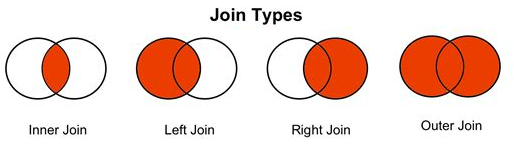

**Пример 1**.

In [15]:
dfL = pd.DataFrame(np.array([1,2,3,4,5,6,7,8,9]).reshape(3, 3),    # создание основного (левого) фрейма
                  index=['1', '2', '3'],
                  columns=['c1', 'c2', 'c3'])
dfR = pd.DataFrame(np.array([21,22,23,24,25,26]).reshape(3, 2),    # создание присоединяемого (правого) фрейма
                  index=['1', '2', '4'],
                  columns=['c4', 'c5'])
print("Основной фрейм \n",dfL)                                     # Вывод первоначальных фреймов
print("\nПрисоединяемый фрейм \n",dfR)
print("\nInner Join \n", dfL.join(dfR, how='inner'))                # Вывод результата внутреннего объединения
print("\nLeft Join \n", dfL.join(dfR, how='left'))                  # Вывод результата левого объединения
print("\nRight Join \n", dfL.join(dfR, how='right'))                # Вывод результата правого объединения
print("\nOuter Join \n", dfL.join(dfR, how='outer'))                # Вывод результата внешнего объединения


Основной фрейм 
    c1  c2  c3
1   1   2   3
2   4   5   6
3   7   8   9

Присоединяемый фрейм 
    c4  c5
1  21  22
2  23  24
4  25  26

Inner Join 
    c1  c2  c3  c4  c5
1   1   2   3  21  22
2   4   5   6  23  24

Left Join 
    c1  c2  c3    c4    c5
1   1   2   3  21.0  22.0
2   4   5   6  23.0  24.0
3   7   8   9   NaN   NaN

Right Join 
     c1   c2   c3  c4  c5
1  1.0  2.0  3.0  21  22
2  4.0  5.0  6.0  23  24
4  NaN  NaN  NaN  25  26

Outer Join 
     c1   c2   c3    c4    c5
1  1.0  2.0  3.0  21.0  22.0
2  4.0  5.0  6.0  23.0  24.0
3  7.0  8.0  9.0   NaN   NaN
4  NaN  NaN  NaN  25.0  26.0


### Слияние (**Merge**)
Если в объединяемых фреймах будут присутствовать одноимённые столбцы, то в общем случае метод **join()** выдаст ошибку, поскольку непонятно, как эти столбцы объединять.

Возможна ситуация, когда данные столбцы по сути являются индексами (однозначно идентифицируют объект - строку фрейма данных). В этом случае для объединения удобно использовать данные этих столбцов, считая их индексами.
Это можно реализовать с помощью метода **merge()**. Параметрами данного метода являются названия объединяемых фреймов, способ объединения (как в методе **join()**) и название столбца, который выполняет роль признака соответствия строк обоих фреймов.

**Пример 2**.
Пусть имеется два фрейма, имеющие каждый по два столбца. В первом фрейме столбцы *Имя* и *Баллы по математике*, а во втором - *Имя* и *Баллы по физике*:

In [16]:
df1=pd.DataFrame({'name': ['Петя','Вася','Коля','Нина','Егор'],
                  'math': [84,57,60,90,74]})
df2=pd.DataFrame({'name': ['Вася','Олег','Саша','Петя'],
                  'phis': [84,57,60,90]})
print("Баллы по математике \n",df1)
print("\nБаллы по физике \n",df2)

Баллы по математике 
    name  math
0  Петя    84
1  Вася    57
2  Коля    60
3  Нина    90
4  Егор    74

Баллы по физике 
    name  phis
0  Вася    84
1  Олег    57
2  Саша    60
3  Петя    90


Признаком для соответствия строк разных фреймов будет значение в столбце *Имя*:

In [17]:
print("\nInner Merge \n", pd.merge(df1, df2, on = 'name'))
print("\nLeft Merge \n", pd.merge(df1, df2, on = 'name', how='left'))
print("\nRight Merge \n", pd.merge(df1, df2, on = 'name', how='right'))
print("\nOuter Merge \n", pd.merge(df1, df2, on = 'name', how='outer'))


Inner Merge 
    name  math  phis
0  Петя    84    90
1  Вася    57    84

Left Merge 
    name  math  phis
0  Петя    84  90.0
1  Вася    57  84.0
2  Коля    60   NaN
3  Нина    90   NaN
4  Егор    74   NaN

Right Merge 
    name  math  phis
0  Вася  57.0    84
1  Олег   NaN    57
2  Саша   NaN    60
3  Петя  84.0    90

Outer Merge 
    name  math  phis
0  Вася  57.0  84.0
1  Егор  74.0   NaN
2  Коля  60.0   NaN
3  Нина  90.0   NaN
4  Олег   NaN  57.0
5  Петя  84.0  90.0
6  Саша   NaN  60.0


Обратите внимание на следующие моменты:
- если метод **join()** - это метод DataFrame (применяется к основному фрейму), то **merge()** - это функция Pandas, при ее использовании имена обоих фреймов (сначала левого, потом правого) указываются в параметрах функции;
- способом объединения по умолчанию является **inner**;
- связывающий столбец указывается в параметре **on**;
- порядок данных в связывающем столбце не важен.


## 3. Временн<b>ы</b>е ряды библиотеки Pandas</font>

Библиотека Pandas была разработана в расчете на построение финансовых моделей и поэтому она содержит широкий набор инструментов для работы с датой и временем, а также с упорядоченными по времени данными (временными рядами).

В этом блокноте рассматриваются лишь некоторые возможности работы с временными рядами в Pandas. Более подробная информация есть в [руководстве пользователя](
https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html)

Данные о дате и времени могут находиться в нескольких видах:
- **Метки даты/времени** ссылаются на конкретные моменты времени (например, 12 мая 2022 года в 07:00 утра).
- **Временные интервалы и периоды** ссылаются на отрезки времени между конкретными начальной и конечной точками (например, 2023 год). Периоды обычно представляют собой особый случай интервалов: непересекающиеся интервалы одинаковой длительности (например, 24-часовые периоды времени, составляющие сутки).
- **Временная дельта** (она же продолжительность) относится к отрезку времени конкретной длительности (например, 12.77 с).


### Структуры данных для временных рядов библиотеки Pandas
- Для меток даты/времени библиотека Pandas предоставляет тип данных **Timestamp**. Это аналог типа данных **datetime** языка Python. Для использования в качестве индекса применяется аналогичный тип **DatetimeIndex**.
- Для периодов времени используется тип данных **Period**. Он кодирует интервал времени фиксированной периодичности. Соответствующая индексная
конструкция — **PeriodIndex**.
- Для временных дельт (продолжительностей) используется тип данных **Timedelta**. Соответствующая индексная конструкция — **TimedeltaIndex**.

Основными объектами даты/времени являются объекты **Timestamp** и **DatetimeIndex**. для обращения к ним удобно использовать функцию **pd.to_datetime()**, которая умеет распознавать запись даты/времени в разных формататах. При передаче в функцию **pd.to_datetime()** отдельной даты она возвращает **Timestamp**, при передаче ряда дат
по умолчанию возвращает **DatetimeIndex**:


In [18]:
from datetime import datetime
import pandas as pd
dates = pd.to_datetime([datetime(2023, 7, 13), '14th of July, 2023', '2023-Jul-16', '17-07-2023', '20230718'])
print(dates)

DatetimeIndex(['2023-07-13', '2023-07-14', '2023-07-16', '2023-07-17',
               '2023-07-18'],
              dtype='datetime64[ns]', freq=None)


Объект **TimedeltaIndex** создается, например, при вычитании одной даты из другой.

Вычтем из серии dates начальную дату:

In [19]:
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[ns]', freq=None)

### Регулярные последовательности дат/времени
Чтобы облегчить создание регулярных последовательностей, Pandas предоставляет несколько функций:
- **pd.date_range()** — для меток даты/времени,
- **pd.period_range()** — для периодов времени и
- **pd.timedelta_range()** — для временных дельт.

Функция **pd.date_range()** создает регулярную последовательность дат, принимая на входе начальную дату, конечную дату и необязательный
код периодичности. По умолчанию период равен одному дню:


In [20]:
pd.date_range('2023-07-03', '2023-07-10')


DatetimeIndex(['2023-07-03', '2023-07-04', '2023-07-05', '2023-07-06',
               '2023-07-07', '2023-07-08', '2023-07-09', '2023-07-10'],
              dtype='datetime64[ns]', freq='D')

В качестве альтернативы можно задавать диапазон дат с помощью не начальной и конечной точек, а посредством начальной точки и количества периодов времени:

In [21]:
pd.date_range('2023-07-03', periods=8)

DatetimeIndex(['2023-07-03', '2023-07-04', '2023-07-05', '2023-07-06',
               '2023-07-07', '2023-07-08', '2023-07-09', '2023-07-10'],
              dtype='datetime64[ns]', freq='D')

Можно изменить интервал времени, поменяв аргумент **freq** , имеющий по умолчанию значение 'D'.

Например, создадим диапазон часовых меток даты/времени:


In [22]:
pd.date_range('2015-07-03', periods=8, freq='H')

/tmp/ipython-input-3521404607.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range('2015-07-03', periods=8, freq='H')


DatetimeIndex(['2015-07-03 00:00:00', '2015-07-03 01:00:00',
               '2015-07-03 02:00:00', '2015-07-03 03:00:00',
               '2015-07-03 04:00:00', '2015-07-03 05:00:00',
               '2015-07-03 06:00:00', '2015-07-03 07:00:00'],
              dtype='datetime64[ns]', freq='h')

### Чтение данных временных рядов из файла и простейшая их обработка



Загрузим содержимое файла *wether.csv* (имеется в материалах занятия в LMS):

In [23]:
df1=pd.read_csv('weather.csv', sep=';')
df1

,datetime,t,p
0,22.12.2023 23:00,0.5,753.7
1,22.12.2023 20:00,0.1,753.4
2,22.12.2023 17:00,0.6,753.1
3,22.12.2023 14:00,3.1,752.9
4,22.12.2023 11:00,2.1,752.5
...,...,...,...
11606,01.01.2020 14:00,-4.2,737.5
11607,01.01.2020 11:00,-6.1,736.0
11608,01.01.2020 08:00,-7.5,734.8
11609,01.01.2020 05:00,-8.5,734.2


Загрузились данные (температура и давление) о погоде в Тюмени, взятые на сайте **rp5.ru**.
- Первая колонка - дата и время сбора показаний датчиков.
- Вторая колонка - температура в градусах Цельсия
- Третья колонка - давление в мм.рт.ст.


Заметно, что данные расположены в обратном порядке по времени. Отсортируем их по признаку **datetime**:

In [24]:
w=df1.sort_values(by = 'datetime')
w

,datetime,t,p
11610,01.01.2020 02:00,NaN,753.7
11609,01.01.2020 05:00,-8.5,734.2
11608,01.01.2020 08:00,-7.5,734.8
11607,01.01.2020 11:00,-6.1,736.0
11606,01.01.2020 14:00,-4.2,737.5
...,...,...,...
2851,31.12.2022 11:00,-24.2,765.4
2850,31.12.2022 14:00,-23.2,765.1
2849,31.12.2022 17:00,-24.6,765.3
2848,31.12.2022 20:00,-25.6,765.4


Не получилось. В последних отображаемых записях фрейма стоит 2022 год. Но мы знаем, что есть много данных за 2023 год.

Причина в том, что в этом столбце время хранится в виде строки. А строка '01.01.2023 02:00' по алфавитному принципу стоит раньше строки '31.12.2022 02:00', хотя это более поздняя календарная дата.

Выход: привести тип данных колонки **datetime** к типу **DatetimeIndex**.

Обратите внимание, в качестве параметра метода **to_datetime** указан **format** (шаблон), который подсказывает методу, какой элемент строки отвечает за тот или иной элемент даты/времени, иначе возможна путаница:

In [25]:
df1.datetime = pd.to_datetime(df1['datetime'], format='%d.%m.%Y %H:%M')
df1

,datetime,t,p
0,2023-12-22 23:00:00,0.5,753.7
1,2023-12-22 20:00:00,0.1,753.4
2,2023-12-22 17:00:00,0.6,753.1
3,2023-12-22 14:00:00,3.1,752.9
4,2023-12-22 11:00:00,2.1,752.5
...,...,...,...
11606,2020-01-01 14:00:00,-4.2,737.5
11607,2020-01-01 11:00:00,-6.1,736.0
11608,2020-01-01 08:00:00,-7.5,734.8
11609,2020-01-01 05:00:00,-8.5,734.2


Данные столбца **datetime** изменились даже внешне. Проверим типы данных в столбцах:

In [26]:
df1.dtypes

,0
datetime,datetime64[ns]
t,float64
p,float64


Теперь можно выполнить сортировку данных по дате/времени:

In [27]:
w=df1.sort_values(by = 'datetime')
w

,datetime,t,p
11610,2020-01-01 02:00:00,NaN,753.7
11609,2020-01-01 05:00:00,-8.5,734.2
11608,2020-01-01 08:00:00,-7.5,734.8
11607,2020-01-01 11:00:00,-6.1,736.0
11606,2020-01-01 14:00:00,-4.2,737.5
...,...,...,...
4,2023-12-22 11:00:00,2.1,752.5
3,2023-12-22 14:00:00,3.1,752.9
2,2023-12-22 17:00:00,0.6,753.1
1,2023-12-22 20:00:00,0.1,753.4


### График временного ряда
Временные ряды интересно визуализировать. Посмотрим график температуры в Тюмени за весь период, который представлен во фрейме.

Для этого вначале сделаем столбец даты/времени индексом:

In [28]:
w.index=w['datetime']
w.drop(['datetime'], axis=1, inplace = True)
w

,t,p
datetime,,
2020-01-01 02:00:00,NaN,753.7
2020-01-01 05:00:00,-8.5,734.2
2020-01-01 08:00:00,-7.5,734.8
2020-01-01 11:00:00,-6.1,736.0
2020-01-01 14:00:00,-4.2,737.5
...,...,...
2023-12-22 11:00:00,2.1,752.5
2023-12-22 14:00:00,3.1,752.9
2023-12-22 17:00:00,0.6,753.1


Построим график температуры. На горизогтальной оси будут отмечаться индексы строк, т.е. временные метки.

<Axes: title={'center': 'Температура в Тюмени'}, xlabel='datetime'>

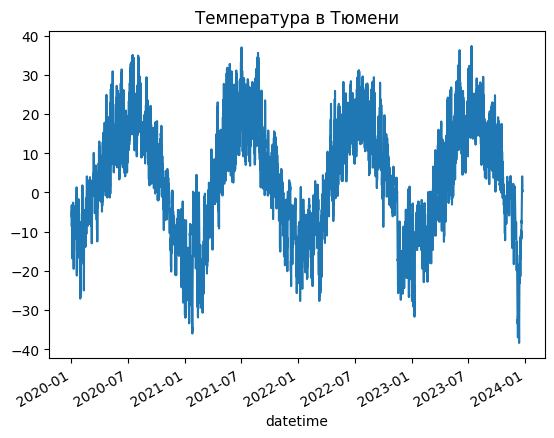

In [29]:
w['t'].plot(title = 'Температура в Тюмени')

Хорошо видна годовая периодичность значений температуры.

Выделим отдельно погоду за последний месяц 2023 года. В загруженном наборе доступны данные только до 23 декабря 2023 года.

In [30]:
w1=w[w.index >= pd.to_datetime('2023-12-01')]
w1

,t,p
datetime,,
2023-12-01 02:00:00,-8.6,752.5
2023-12-01 05:00:00,-8.9,753.0
2023-12-01 08:00:00,-9.1,753.1
2023-12-01 11:00:00,-8.8,753.0
2023-12-01 14:00:00,-9.3,753.4
...,...,...
2023-12-22 11:00:00,2.1,752.5
2023-12-22 14:00:00,3.1,752.9
2023-12-22 17:00:00,0.6,753.1


Построим график:

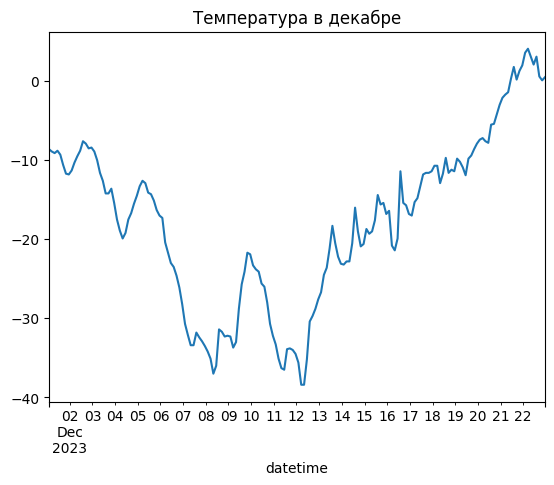

In [31]:
w1['t'].plot(title = 'Температура в декабре');

Pandas предоставляет методы для изменения частоты дискретизации данных временных рядов.

Первоначально временные отметки шли с интервалом 3 часа (6 отметок в сутки). В примере ниже мы сформируем набор данных ежедневных параметров декабря заменив данные одного дня (параметр 'D') средним значением (mean):

In [32]:
w_daily=w1.resample('D').mean()
w_daily

,t,p
datetime,,
2023-12-01,-9.8500,753.0250
2023-12-02,-9.0375,746.9250
2023-12-03,-12.5625,743.0250
2023-12-04,-17.4625,755.9875
2023-12-05,-14.4500,747.1000
2023-12-06,-23.1000,755.6375
2023-12-07,-32.5250,770.0375
2023-12-08,-33.7375,772.9750
2023-12-09,-27.6500,770.2125


Фо фрейме осталось 22 строки (по числу дней). Построим по ним график температуры:

<Axes: title={'center': 'Температура в декабре'}, xlabel='datetime'>

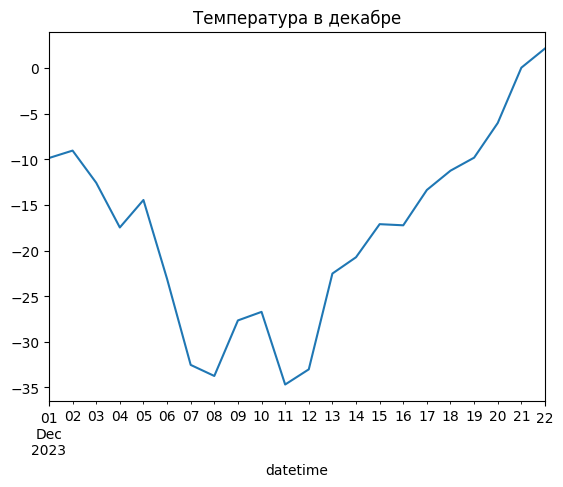

In [33]:
w_daily['t'].plot(title = 'Температура в декабре')

Заметно, что пропала плавность и график выглядит как ломаная

Pandas позволяет применить к значениям временного ряда сглаживание методом скользящей средней. Суть метода в том, что значение каждой точки временного ряда заменяется средним значением во временном диапазоне с центром в данной временной точке. Размер диапазона (**window**) задаётся:

<Axes: title={'center': 'Температура в декабре'}, xlabel='datetime'>

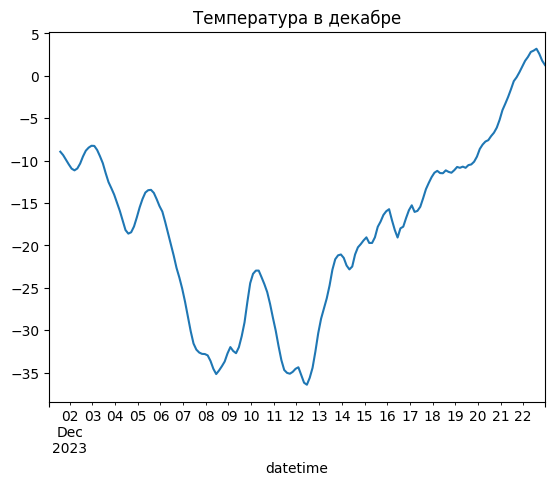

In [34]:
w_rolling = w1.rolling(window=5).mean()
w_rolling['t'].plot(title = 'Температура в декабре')